# Unsupervised Discovery of Urban Mobility Archetypes from High-Volume NYC Taxi Trip Records

**MSc Big Data Analytics: Research Project**
**Candidate:** Rubin Apore (Student ID: 22495624)

This notebook executes the full six-layer unsupervised learning pipeline described in
`nyc_taxi_urban_mobility_proposal.pdf` against the real NYC TLC Yellow Taxi Trip Records for
January–June 2023 (~19.5M raw trips). Each layer below mirrors `src/run_pipeline.py`; running
this notebook top-to-bottom reproduces every figure and number reported in the dissertation
write-up (`reports/dissertation/`).

**Research questions**

- **RQ1 (Spatial):** What demand archetypes emerge when NYC taxi zones are characterised by volume, revenue, behavioural, and temporal profiles?
- **RQ2 (Temporal):** Do taxi zones share demand rhythm *shapes* independent of absolute volume?
- **RQ3 (Structural):** What latent spatiotemporal demand components can be extracted from the Zone × Hour × DayType tensor?
- **RQ4 (Anomaly):** Which individual trips are structurally unusual, and which zones concentrate this behaviour?
- **RQ5 (Synthesis):** Does a unified multi-layer zone fingerprint produce a coherent low-dimensional embedding reflecting NYC's functional geography?


In [1]:
import sys
sys.path.insert(0, "..")

import json
import time
import numpy as np
import pandas as pd
from IPython.display import Image, display

_notebook_start = time.time()

from src import config
from src import layer1_load_filter as L1
from src import layer2_kmeans as L2
from src import layer3_kshape as L3
from src import layer4_tucker as L4
from src import layer5_isoforest as L5
from src import layer6_umap as L6
from src import viz
from src.build_narrative import build_narrative, save_narrative

pd.set_option("display.max_columns", 30)


/home/rapore/projects/bdat_project/venv/lib/python3.12/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


/home/rapore/projects/bdat_project/venv/lib/python3.12/site-packages/tensorly/solvers/nnls.py:18: SyntaxWarning: invalid escape sequence '\l'
  """
/home/rapore/projects/bdat_project/venv/lib/python3.12/site-packages/tensorly/solvers/admm.py:27: SyntaxWarning: invalid escape sequence '\_'
  """


## Layer 1: Data Loading, Quality Filtering, Feature Engineering

Streams through the six monthly Parquet files, applies the domain-knowledge quality filters
(duration, distance, fare, speed, valid zone IDs), engineers trip-level features, and folds the
results into a zone-level profile, a Zone×Hour×DayType demand tensor, and a ~500,000-trip random
sample used later for anomaly detection, all without materialising the full 19.5M-row dataset in
memory at once.

In [2]:
zone_profile, tensor_counts, sample_trips, qc1 = L1.run_layer1()
qc1

[Layer 1] Loading yellow_tripdata_2023-01.parquet (1/6) ...


    raw=3,066,766  kept=2,932,729  retention=95.6%  sample_frac=0.0284
[Layer 1] Loading yellow_tripdata_2023-02.parquet (2/6) ...


    raw=2,913,955  kept=2,789,964  retention=95.7%  sample_frac=0.0299
[Layer 1] Loading yellow_tripdata_2023-03.parquet (3/6) ...


    raw=3,403,766  kept=3,265,757  retention=95.9%  sample_frac=0.0255
[Layer 1] Loading yellow_tripdata_2023-04.parquet (4/6) ...


    raw=3,288,250  kept=3,157,041  retention=96.0%  sample_frac=0.0264
[Layer 1] Loading yellow_tripdata_2023-05.parquet (5/6) ...


    raw=3,513,649  kept=3,369,803  retention=95.9%  sample_frac=0.0247
[Layer 1] Loading yellow_tripdata_2023-06.parquet (6/6) ...


    raw=3,307,234  kept=3,165,806  retention=95.7%  sample_frac=0.0263
[Layer 1] Done in 18.1s. QC: {'raw_trip_count': 19493620, 'filtered_trip_count': 18681100, 'retention_rate': 0.9583186704162695, 'n_zones_with_data': 260, 'sample_trip_count': 499998, 'elapsed_seconds': 18.1}


{'raw_trip_count': 19493620,
 'filtered_trip_count': 18681100,
 'retention_rate': 0.9583186704162695,
 'n_zones_with_data': 260,
 'sample_trip_count': 499998,
 'elapsed_seconds': 18.1}

In [3]:
zone_profile.head()

,zone_id,trip_count,log_trip_count,mean_fare,mean_distance,mean_duration,mean_speed,mean_tip_pct,pct_weekend,pct_cash,pct_night,pct_rush,Borough,Zone,service_zone
0,1,123.0,4.820282,91.988618,14.025610,35.737534,24.081498,0.155841,0.284553,0.138211,0.195122,0.382114,EWR,Newark Airport,EWR
1,2,13.0,2.639057,46.738462,12.220000,32.019231,22.849887,0.119340,0.307692,0.153846,0.076923,0.384615,Queens,Jamaica Bay,Boro Zone
2,3,261.0,5.568345,33.145134,7.522759,37.156577,12.065190,0.012712,0.099617,0.072797,0.049808,0.417625,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,22790.0,10.034121,17.365128,3.077565,14.883209,11.931040,0.193228,0.555331,0.111101,0.564239,0.210750,Manhattan,Alphabet City,Yellow Zone
4,5,259.0,5.560682,64.299614,18.579653,60.921171,20.051606,0.009864,0.308880,0.000000,0.115830,0.378378,Staten Island,Arden Heights,Boro Zone


## Layer 2: K-Means Spatial Clustering (RQ1)

Zones are described by a 10-feature profile (volume, fare, distance, duration, speed, tip
share, weekend/cash/night/rush shares), standardised and clustered with K-Means. *k* is
selected by silhouette score across k=2..8. The silhouette-optimal k is reported alongside
k=5, which is adopted as the primary solution for its materially richer interpretability
(see dissertation Section 5.1 for the full justification).

In [4]:
l2_df, l2_X, l2_km, result2 = L2.run_layer2(zone_profile, forced_k=5)
print("Statistically-optimal k:", result2["best_k"], "| k used:", result2["k_used"])
pd.DataFrame(result2["cluster_summary"])

Statistically-optimal k: 2 | k used: 5


,kmeans_cluster,trip_count,mean_fare,mean_distance,pct_night,pct_cash,n_zones
0,0,2733.000000,28.735497,5.520889,0.175322,0.280715,56
1,1,298740.962264,16.909397,2.854376,0.153131,0.175083,53
2,2,51890.315789,24.943362,4.827859,0.487049,0.152891,19
3,3,717.047059,31.799234,6.946470,0.117406,0.088773,85
4,4,35062.042553,51.145328,12.287678,0.176943,0.138340,47


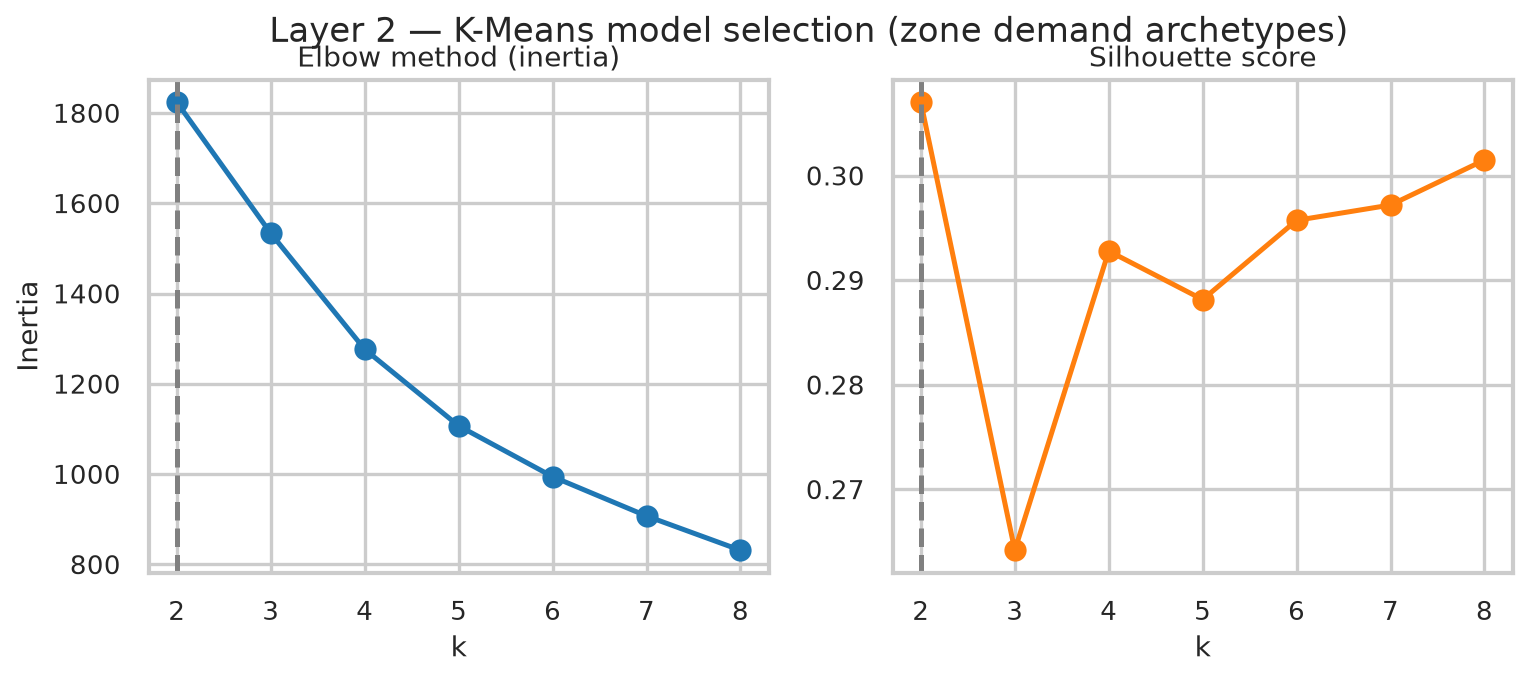

/home/rapore/projects/bdat_project/notebooks/../src/viz.py:51: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.violinplot(
/home/rapore/projects/bdat_project/notebooks/../src/viz.py:51: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.violinplot(


/home/rapore/projects/bdat_project/notebooks/../src/viz.py:51: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.violinplot(
/home/rapore/projects/bdat_project/notebooks/../src/viz.py:51: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.violinplot(
/home/rapore/projects/bdat_project/notebooks/../src/viz.py:51: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.violinplot(


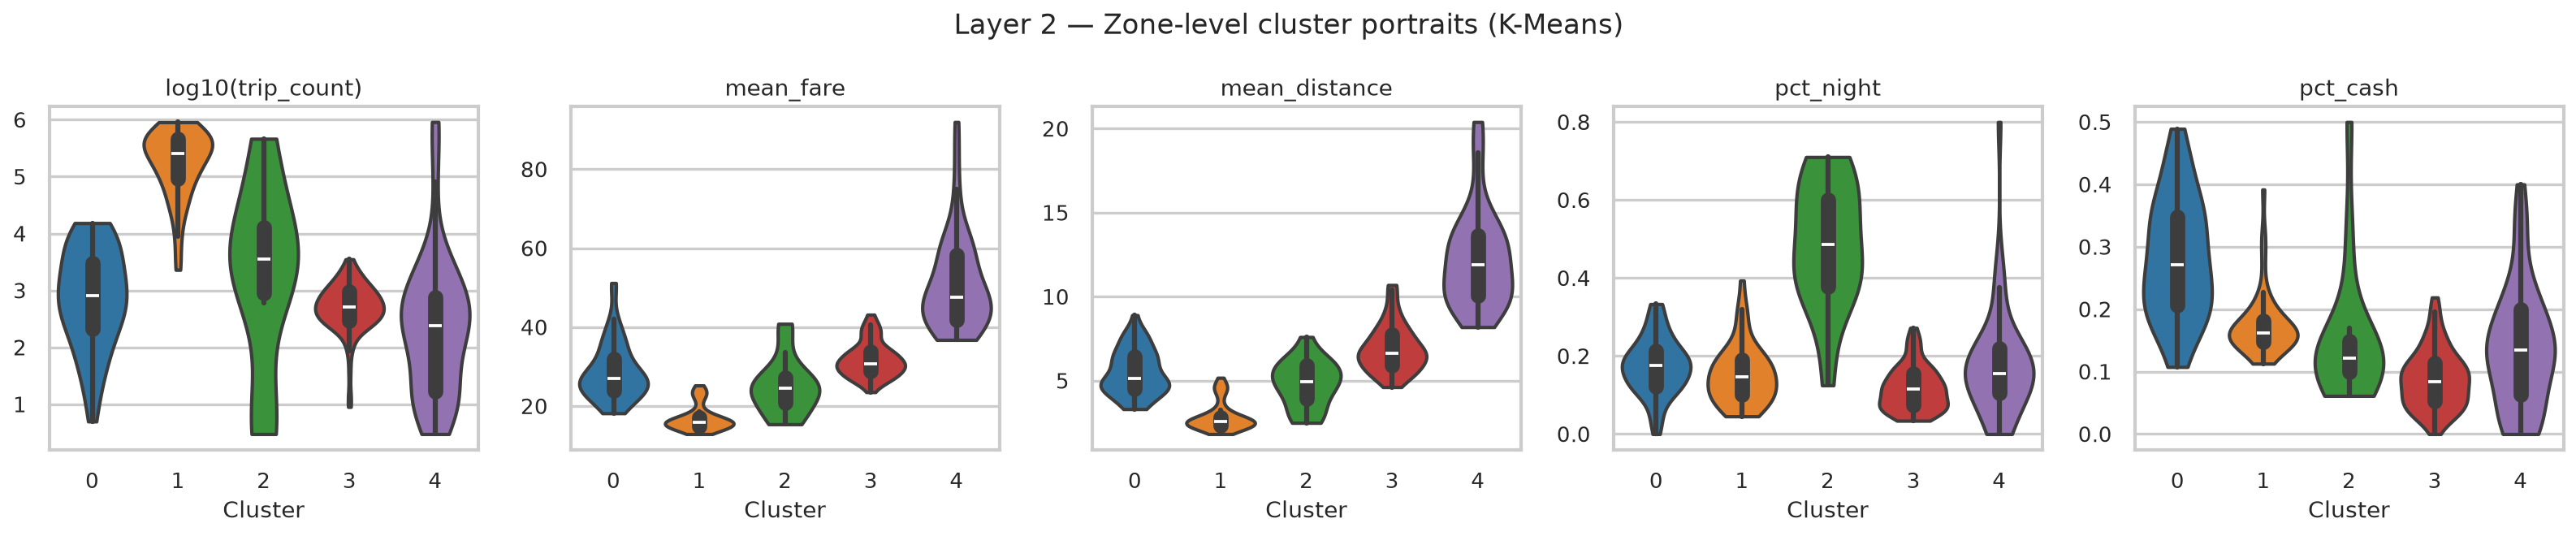

In [5]:
display(Image(str(viz.plot_kmeans_selection(result2["inertias"], result2["silhouettes"], result2["best_k"]))))
display(Image(str(viz.plot_kmeans_violins(l2_df))))

## Layer 3: K-Shape Temporal Rhythm Clustering (RQ2)

Each zone's 24-hour demand profile is normalised to a fractional share and z-normalised
(shape-only, volume- and offset-invariant) before K-Shape clustering. Zones averaging fewer
than 10 trips/day are excluded to avoid sparsity-induced shape distortion.

In [6]:
l3_df, l3_shares, l3_centroids, result3 = L3.run_layer3(zone_profile, tensor_counts)
print("Active zones:", result3["n_active_zones"], "| Selected k:", result3["best_k"])
result3["borough_mix"]

Active zones: 99 | Selected k: 3


{'0': {'Manhattan': 48, 'Queens': 11, 'Brooklyn': 3},
 '1': {'Brooklyn': 8, 'Manhattan': 6},
 '2': {'Brooklyn': 9, 'Queens': 8, 'Manhattan': 6}}

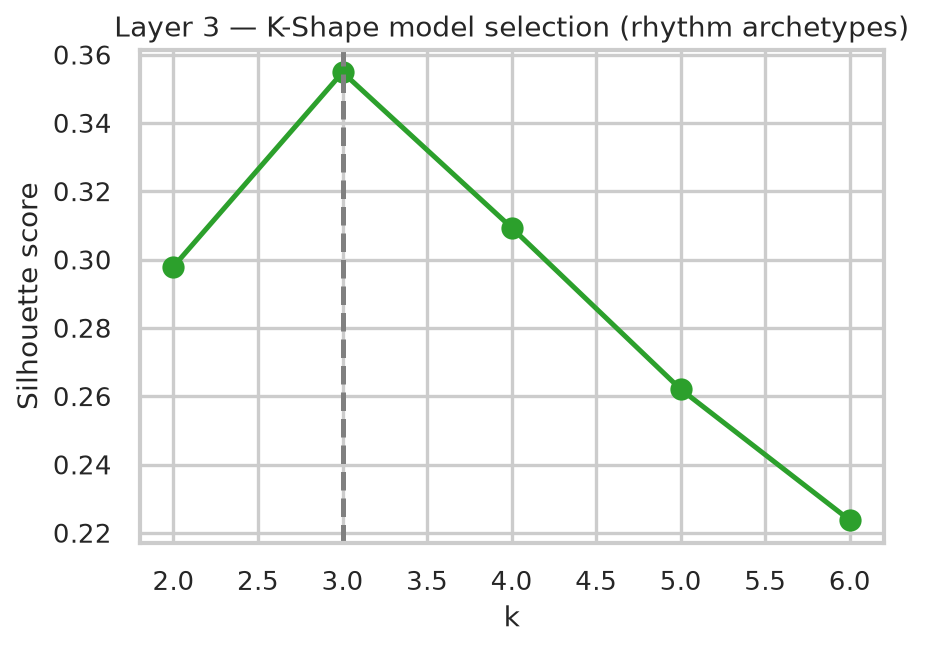

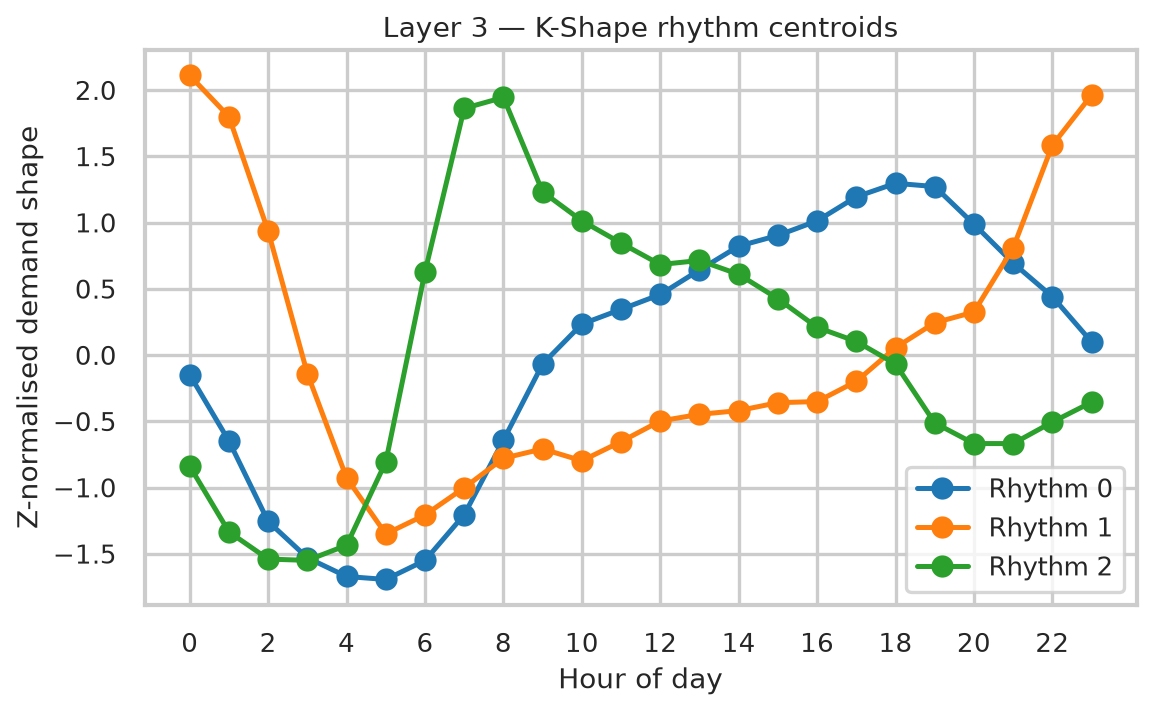

In [7]:
display(Image(str(viz.plot_kshape_selection(result3["silhouettes"], result3["best_k"]))))
display(Image(str(viz.plot_kshape_centroids(l3_centroids))))

## Layer 4: Non-negative Tucker Decomposition (RQ3)

The Zone×Hour×DayType demand tensor (263 × 24 × 2) is decomposed with non-negative Tucker
decomposition at core rank (6, 4, 2), with reconstruction-error sensitivity checked against
neighbouring ranks.

In [8]:
core, zone_factors, hour_factors, daytype_factors, result4 = L4.run_layer4(tensor_counts)
result4

{'primary_rank': [6, 4, 2],
 'reconstruction_error': 0.13394639258388694,
 'explained_variance': 0.9820583639137632,
 'rank_sensitivity': {'(4, 3, 2)': 0.16079208429370218,
  '(5, 4, 2)': 0.11673108899920549,
  '(6, 4, 2)': 0.14420149950264535,
  '(8, 4, 2)': 0.14466458262637705}}

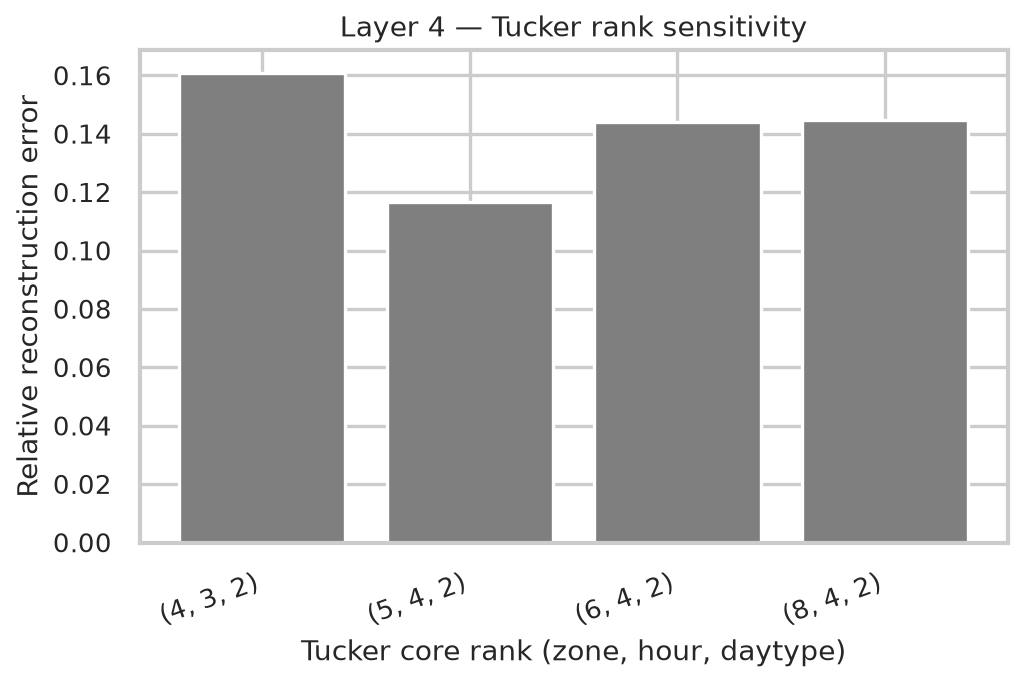

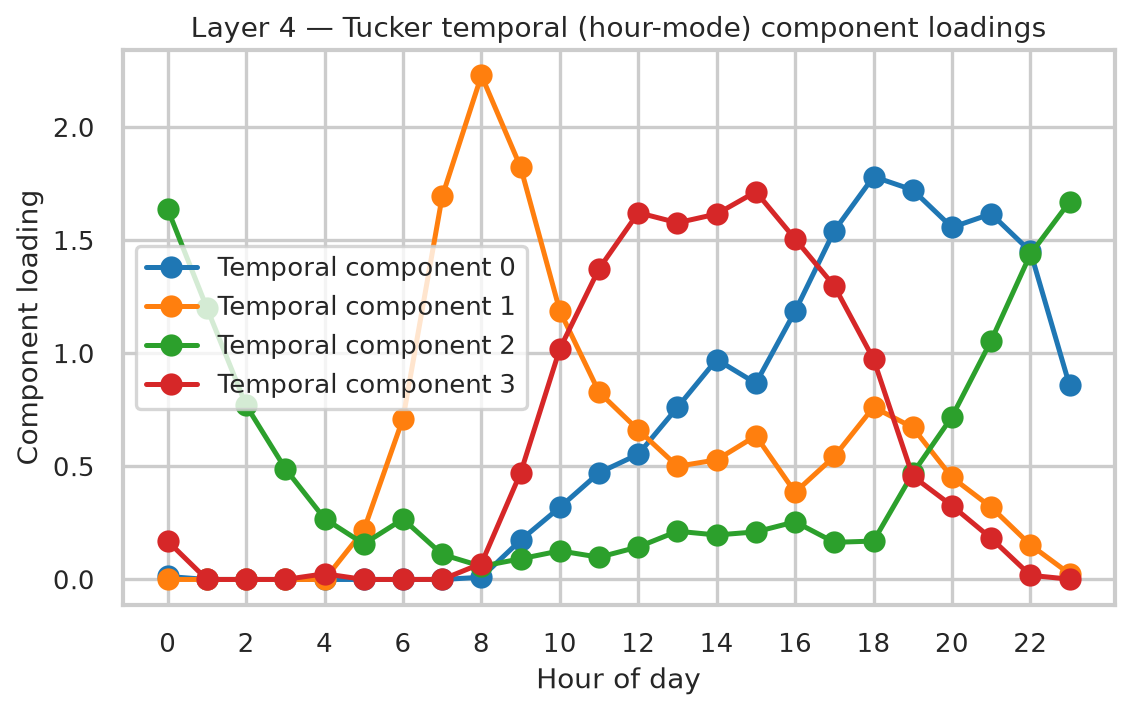

/home/rapore/projects/bdat_project/notebooks/../src/viz.py:125: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.scatterplot(data=df, x="zf0", y="zf1", hue="Borough", palette=PALETTE, ax=ax, s=45)


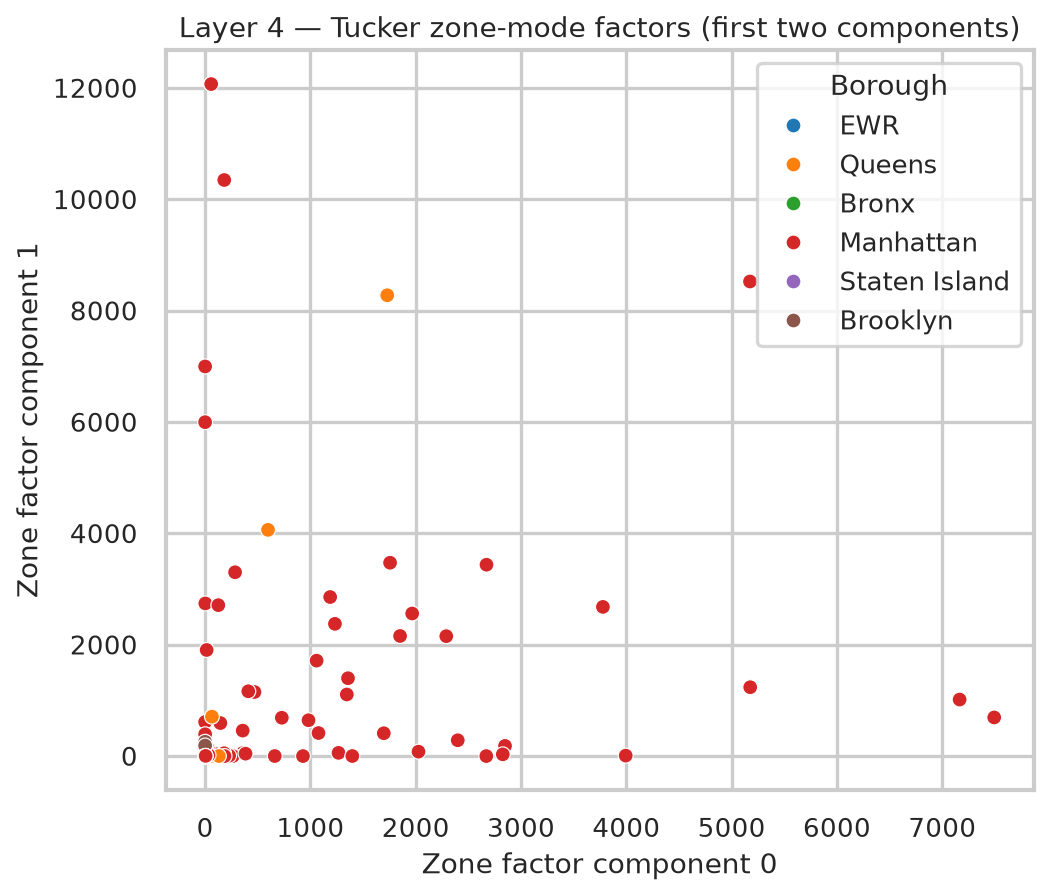

In [9]:
display(Image(str(viz.plot_tucker_rank_sensitivity(result4["rank_sensitivity"], result4["primary_rank"]))))
display(Image(str(viz.plot_tucker_hour_factors(hour_factors))))
display(Image(str(viz.plot_tucker_zone_scatter(zone_factors, zone_profile))))

## Layer 5: Isolation Forest Trip-Level Anomaly Detection (RQ4)

An Isolation Forest (200 trees, 2% contamination) is fit on the 500,000-trip representative
sample using 7 trip-level features. Stability is checked by refitting independently on two
random halves of the sample and correlating the resulting per-zone anomaly rates.

In [10]:
l5_df, zone_rate, result5 = L5.run_layer5(sample_trips)
{k: v for k, v in result5.items() if k != "top_anomaly_zones"}

{'n_sampled': 499998,
 'n_anomalies': 10000,
 'anomaly_share': 0.02000008000032,
 'median_fare_anomaly': 70.0,
 'median_fare_normal': 12.8,
 'median_speed_anomaly': 26.647888956174278,
 'median_speed_normal': 9.832203000963613,
 'median_distance_anomaly': 18.8,
 'median_distance_normal': 1.8,
 'stability_correlation_between_random_halves': 0.5504968614120462}

In [11]:
pd.DataFrame(result5["top_anomaly_zones"])

,zone_id,anomaly_rate,n_sampled
0,8,1.000000,1
1,6,1.000000,1
2,172,1.000000,1
3,23,0.933333,15
4,5,0.714286,7
5,214,0.666667,3
6,118,0.500000,2
7,98,0.500000,2
8,11,0.500000,4
9,150,0.500000,4


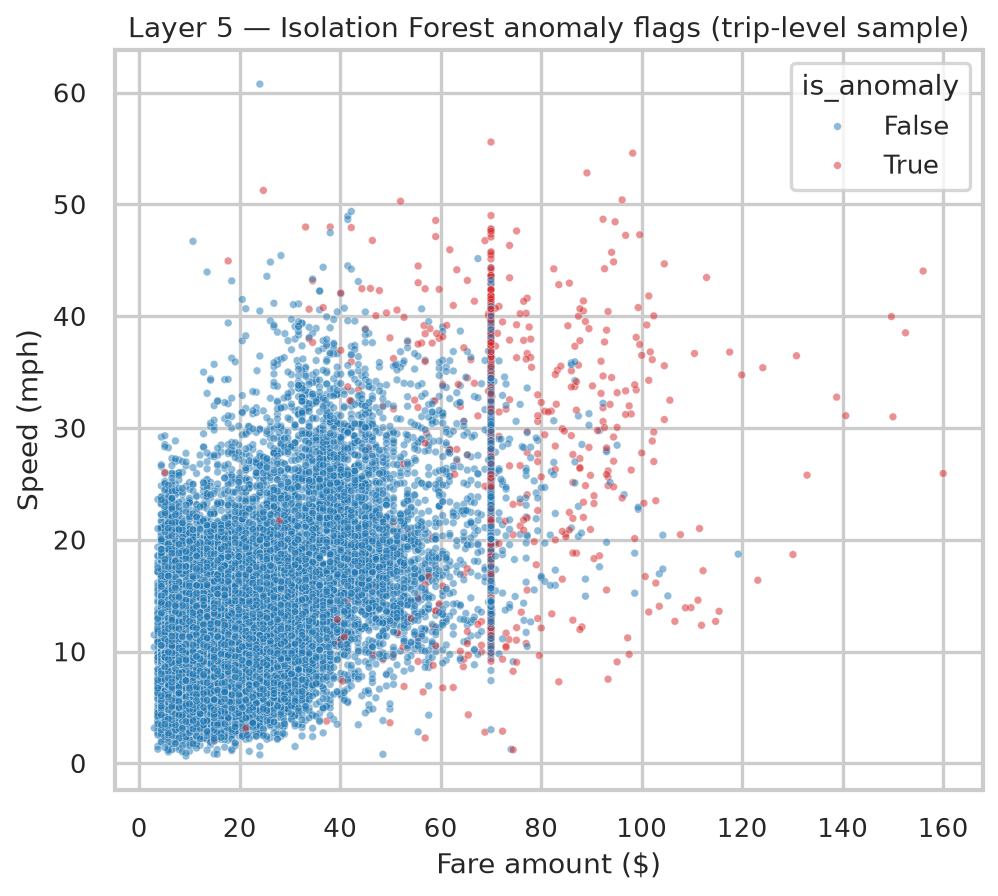

/home/rapore/projects/bdat_project/notebooks/../src/viz.py:152: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(data=df, y="Zone", x="anomaly_rate", hue="Borough", dodge=False, palette=PALETTE, ax=ax)


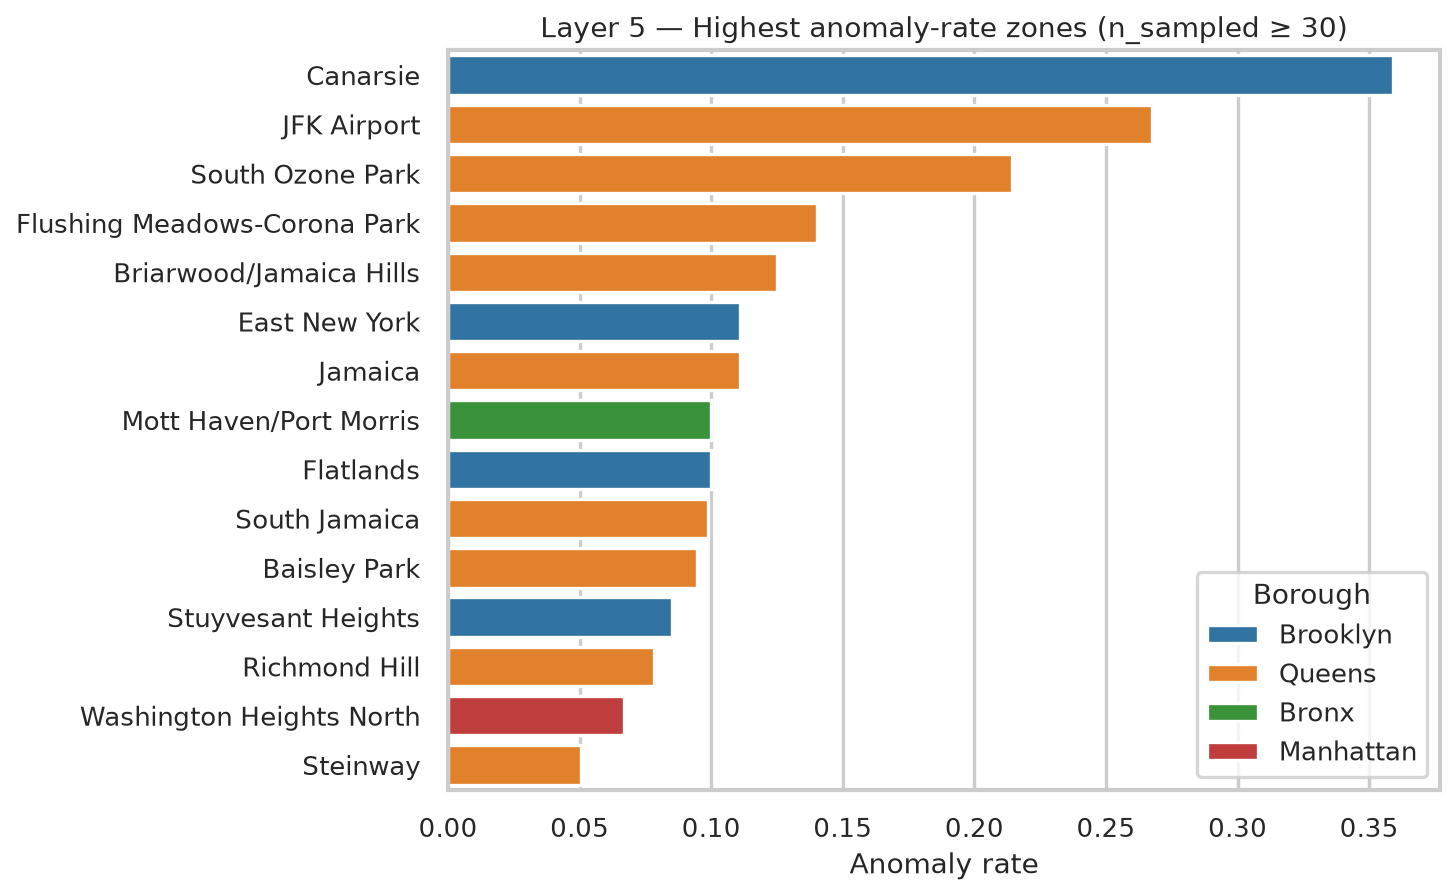

In [12]:
display(Image(str(viz.plot_isoforest_scatter(l5_df))))
display(Image(str(viz.plot_isoforest_zone_heatmap(zone_rate, zone_profile))))

## Layer 6: UMAP Unified Zone Fingerprint (RQ5)

Each zone's 17-dimensional fingerprint (10 K-Means features + 6 Tucker zone-mode factors + 1
anomaly rate) is embedded into 2D with UMAP, coloured by borough and by the Layer 2 K-Means
cluster, with a PCA baseline for comparison.

In [13]:
l6_df, result6 = L6.run_layer6(zone_profile, zone_factors, zone_rate)
l6_df = l6_df.merge(l2_df[["zone_id", "kmeans_cluster"]], on="zone_id", how="left")
result6

/home/rapore/projects/bdat_project/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'n_zones': 260,
 'n_fingerprint_dims': 17,
 'fingerprint_features': ['log_trip_count',
  'mean_fare',
  'mean_distance',
  'mean_duration',
  'mean_speed',
  'mean_tip_pct',
  'pct_weekend',
  'pct_cash',
  'pct_night',
  'pct_rush',
  'tucker_zf_0',
  'tucker_zf_1',
  'tucker_zf_2',
  'tucker_zf_3',
  'tucker_zf_4',
  'tucker_zf_5',
  'anomaly_rate'],
 'pca_explained_variance_ratio': [0.3396810372240151, 0.14872883434475845]}

/home/rapore/projects/bdat_project/notebooks/../src/viz.py:164: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.scatterplot(data=df, x="umap_x", y="umap_y", hue="Borough", palette=PALETTE, s=55, ax=axes[0])
/home/rapore/projects/bdat_project/notebooks/../src/viz.py:167: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.scatterplot(


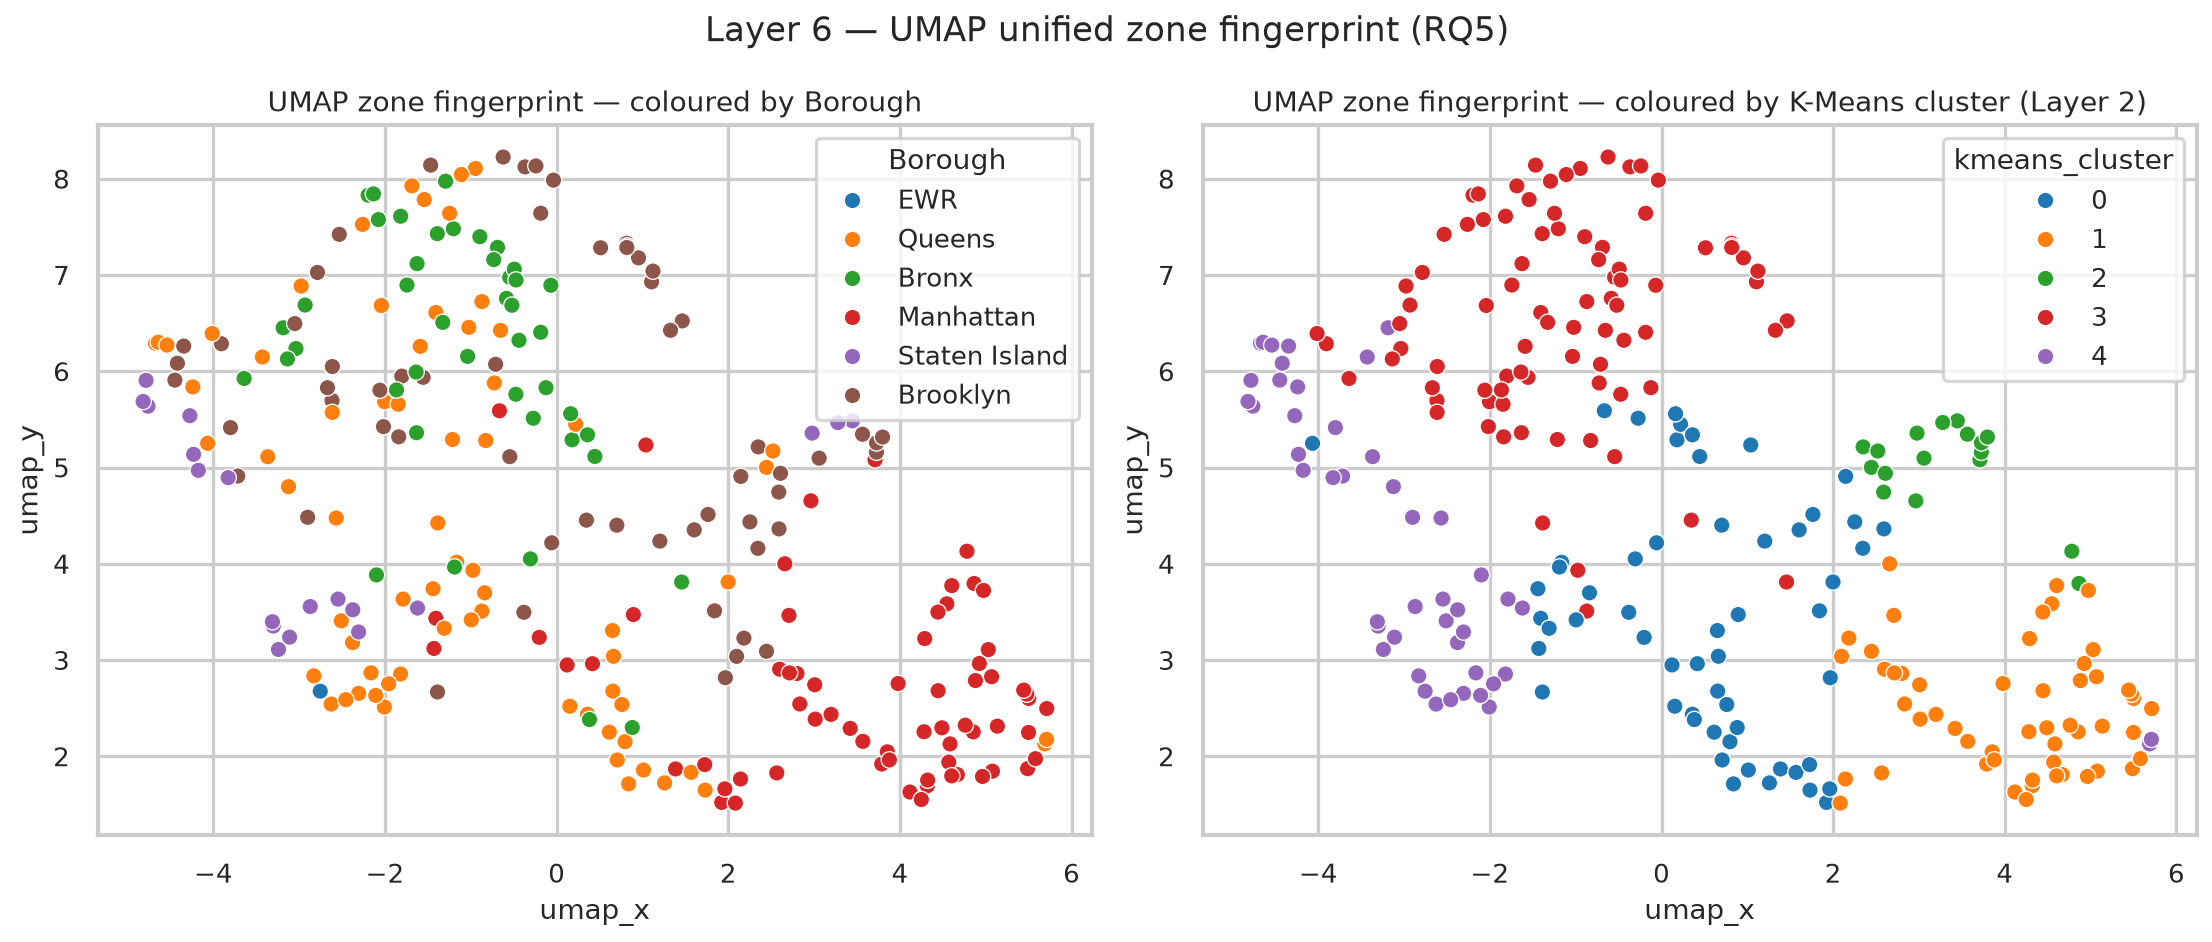

/home/rapore/projects/bdat_project/notebooks/../src/viz.py:178: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.scatterplot(data=df, x="umap_x", y="umap_y", hue="Borough", palette=PALETTE, s=45, ax=axes[0], legend=False)
/home/rapore/projects/bdat_project/notebooks/../src/viz.py:180: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.scatterplot(data=df, x="pca_x", y="pca_y", hue="Borough", palette=PALETTE, s=45, ax=axes[1])


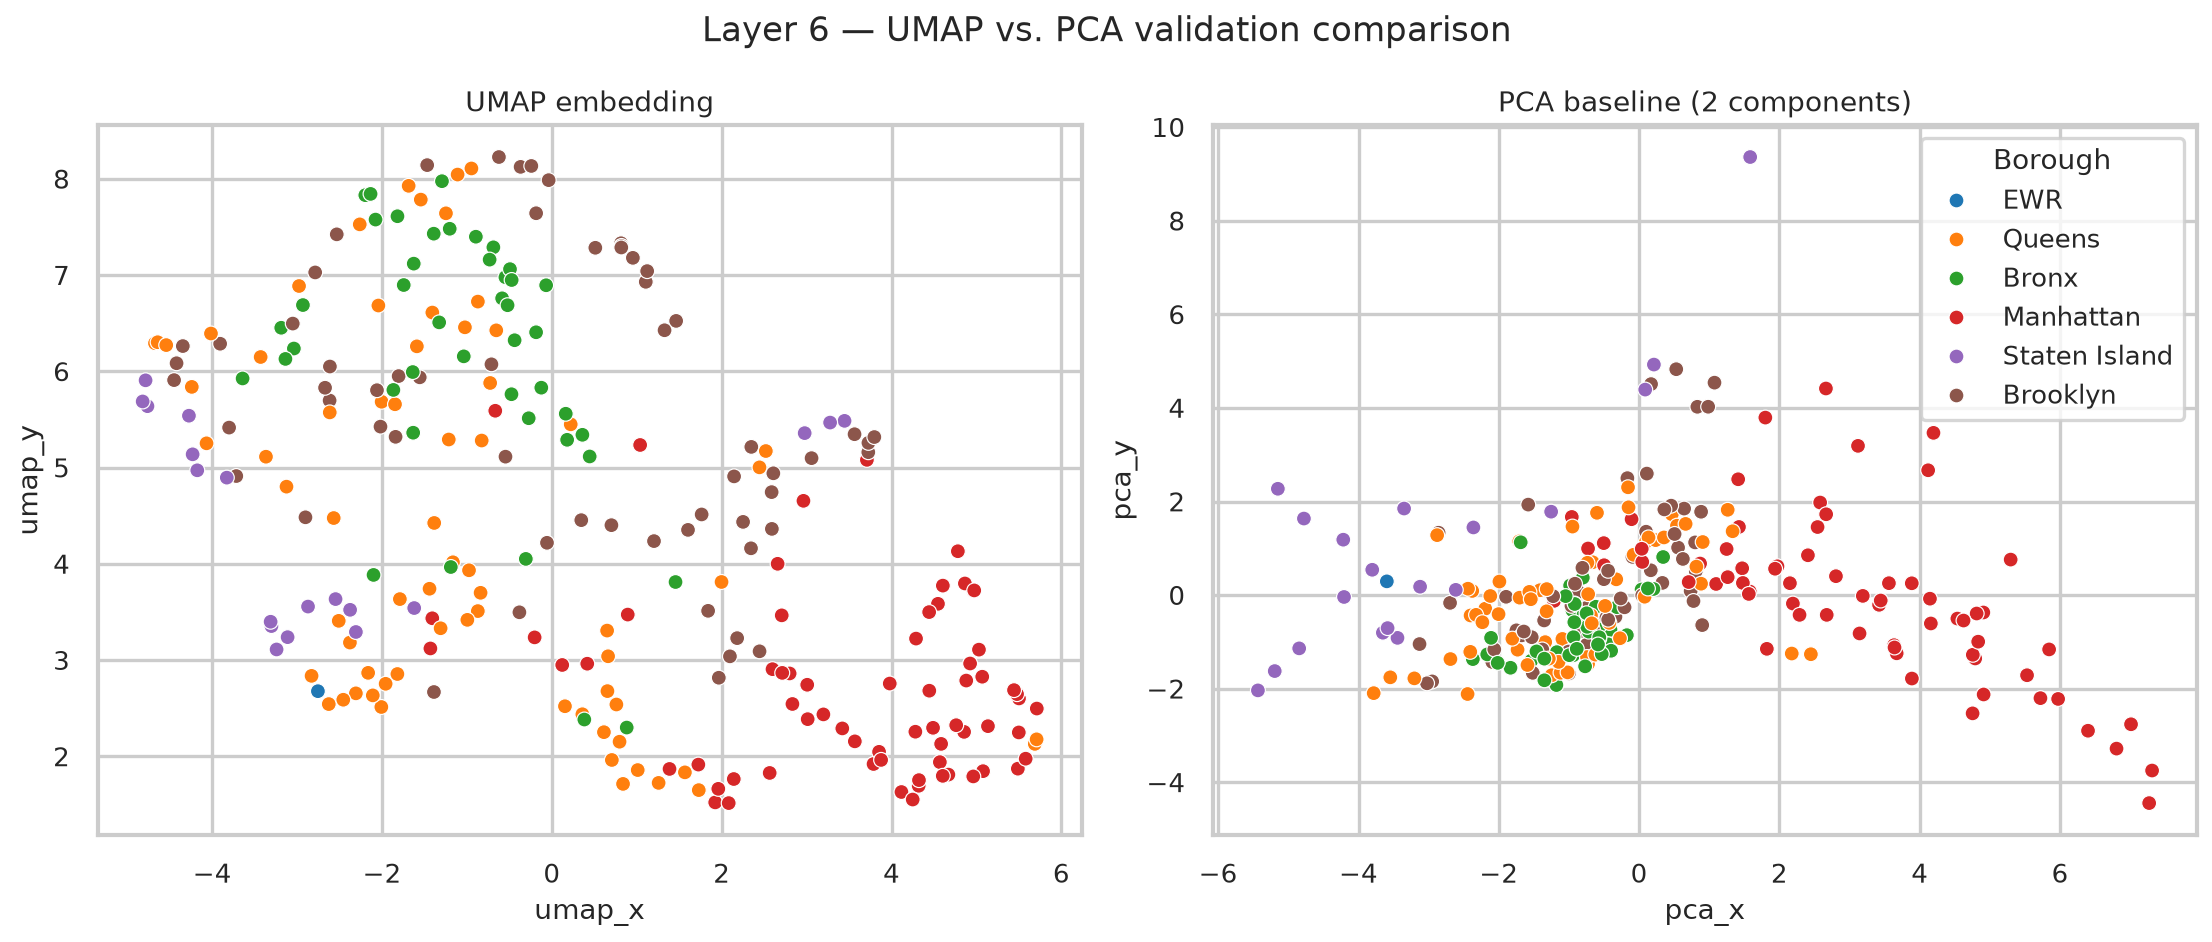

In [14]:
display(Image(str(viz.plot_umap(l6_df))))
display(Image(str(viz.plot_umap_vs_pca(l6_df))))

## Persisting artefacts

All intermediate artefacts and a consolidated `results_summary.json` (used to populate the
dissertation write-up with real numbers) are saved under `data/processed/`.

In [15]:
config.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
zone_profile.to_parquet(config.PROCESSED_DIR / "zone_profile.parquet")
np.save(config.PROCESSED_DIR / "tensor_counts.npy", tensor_counts)
sample_trips.to_parquet(config.PROCESSED_DIR / "sample_trips.parquet")
l2_df.to_parquet(config.PROCESSED_DIR / "layer2_kmeans_zones.parquet")
l3_df.to_parquet(config.PROCESSED_DIR / "layer3_kshape_zones.parquet")
np.save(config.PROCESSED_DIR / "layer3_centroids.npy", l3_centroids)
np.save(config.PROCESSED_DIR / "layer4_core.npy", core)
np.save(config.PROCESSED_DIR / "layer4_zone_factors.npy", zone_factors)
np.save(config.PROCESSED_DIR / "layer4_hour_factors.npy", hour_factors)
np.save(config.PROCESSED_DIR / "layer4_daytype_factors.npy", daytype_factors)
zone_rate.to_parquet(config.PROCESSED_DIR / "layer5_zone_anomaly_rate.parquet")
l6_df.to_parquet(config.PROCESSED_DIR / "layer6_umap_zones.parquet")

summary = {
    "layer1": qc1, "layer2": result2, "layer3": result3,
    "layer4": result4, "layer5": result5, "layer6": result6,
    "total_elapsed_seconds": round(time.time() - _notebook_start, 1),
}
with open(config.RESULTS_JSON, "w") as f:
    json.dump(summary, f, indent=2, default=str)
print("Saved results_summary.json")

narrative = build_narrative(
    zone_profile, l2_df, l3_df, zone_rate, zone_factors, hour_factors,
    daytype_factors, l3_centroids, summary,
)
narrative_path = save_narrative(narrative)
print(f"Saved {narrative_path}")

Saved results_summary.json
Saved /home/rapore/projects/bdat_project/data/processed/narrative_data.json
